Saving iris.csv to iris.csv
   Unnamed: 0  Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0           1           5.1          3.5           1.4          0.2  setosa
1           2           4.9          3.0           1.4          0.2  setosa
2           3           4.7          3.2           1.3          0.2  setosa
3           4           4.6          3.1           1.5          0.2  setosa
4           5           5.0          3.6           1.4          0.2  setosa

Dataset Shape: (150, 6)

Dataset after removing unnecessary column:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Ran

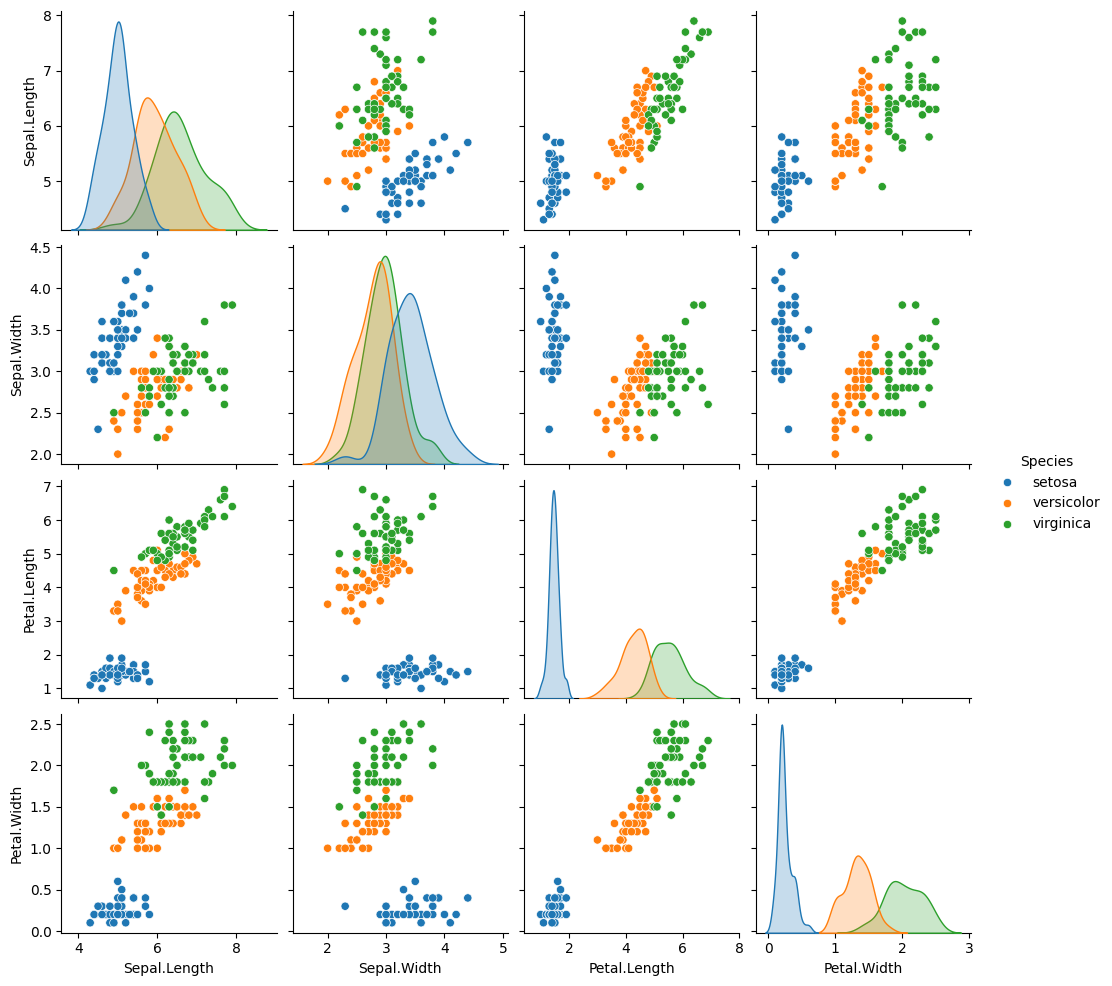

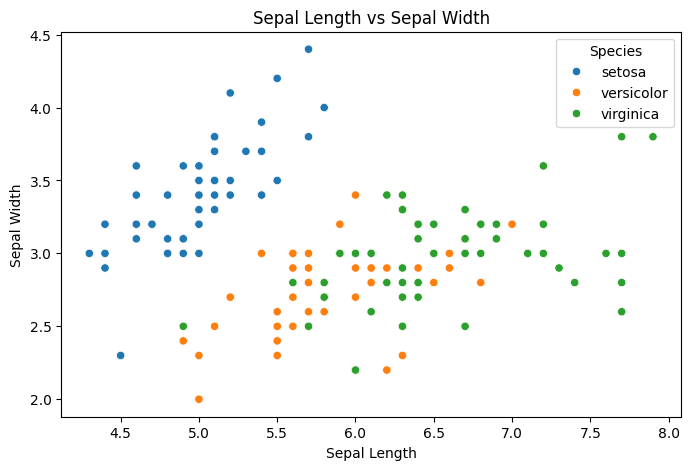

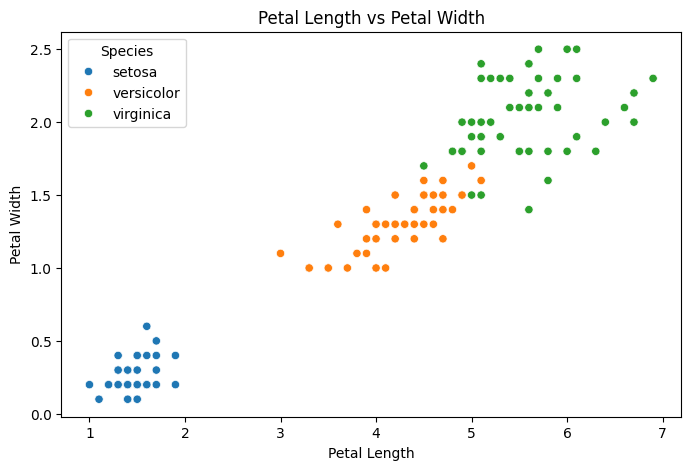

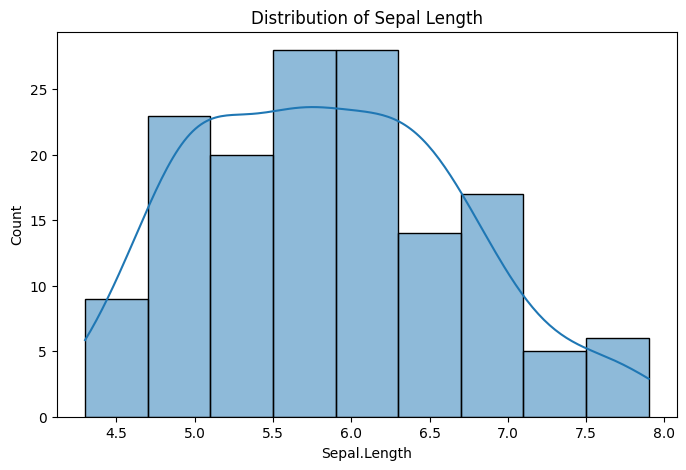

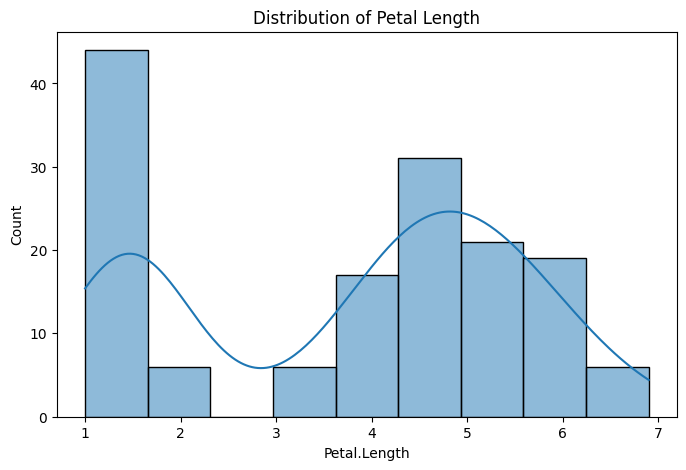

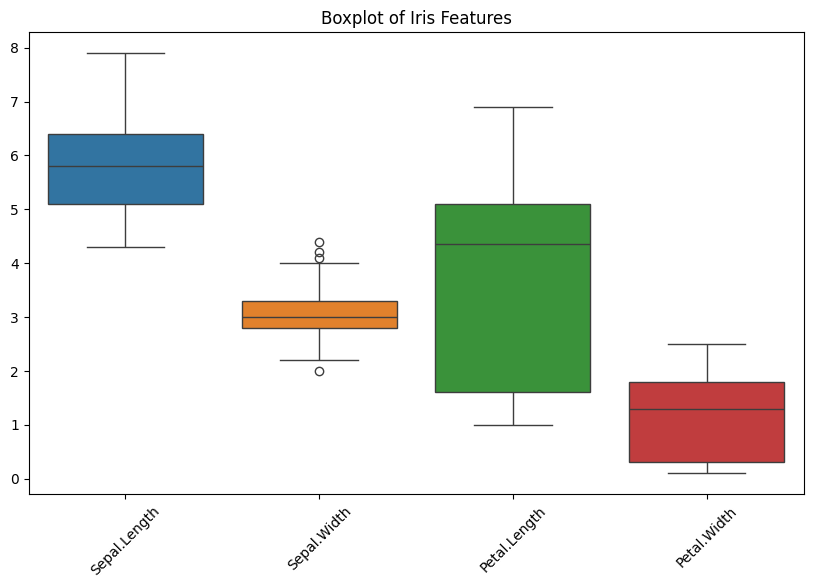


Correlation Matrix:
              Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Sepal.Length      1.000000    -0.117570      0.871754     0.817941
Sepal.Width      -0.117570     1.000000     -0.428440    -0.366126
Petal.Length      0.871754    -0.428440      1.000000     0.962865
Petal.Width       0.817941    -0.366126      0.962865     1.000000


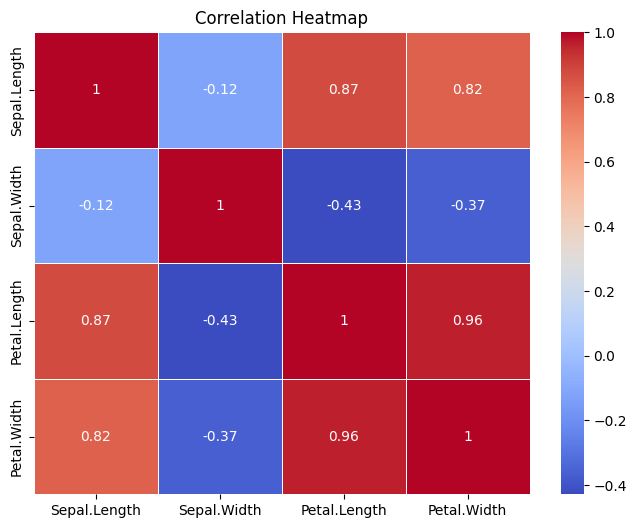

Training data shape: (112, 4)
Testing data shape: (38, 4)

LOGISTIC REGRESSION
Accuracy: 0.9473684210526315

Confusion Matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  1 12]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38


SUPPORT VECTOR MACHINE
Accuracy: 0.9210526315789473

K NEAREST NEIGHBORS
Accuracy: 0.9736842105263158

GAUSSIAN NAIVE BAYES
Accuracy: 0.9210526315789473

DECISION TREE
Accuracy: 0.8947368421052632

MODEL COMPARISON
                    Model  Accuracy  Accuracy (%)
0     K Nearest Neighbors  0.973684     97.368421
1     Logistic Regression  0.947368     94.736842
2  Support Vector Machine  0.921053     92.105263
3    Gaussian N

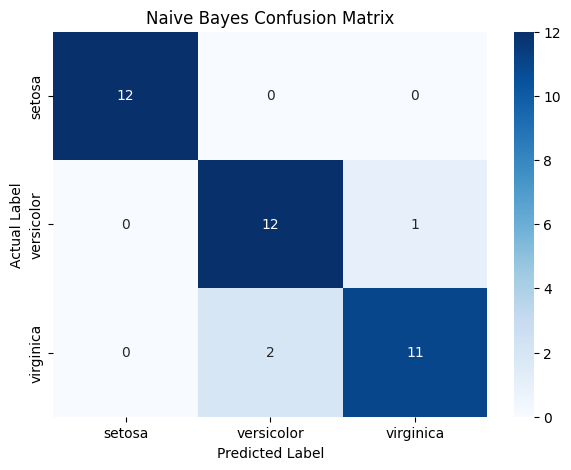


CONCLUSION
The Iris dataset was analyzed using Exploratory Data Analysis and five machine learning classification algorithms.
The models were compared using their accuracy scores.
The model with the highest accuracy was: K Nearest Neighbors
Best Accuracy: 97.37 %


In [3]:
# ============================================
# IRIS FLOWER CLASSIFICATION PROJECT
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings(action='ignore')


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------
from google.colab import files

uploaded = files.upload()
iris = pd.read_csv("iris.csv")

print(iris.head())
print("\nDataset Shape:", iris.shape)


# --------------------------------------------
# 3. Remove Unnecessary Index Column
# --------------------------------------------

if 'Unnamed: 0' in iris.columns:
    iris = iris.drop('Unnamed: 0', axis=1)

print("\nDataset after removing unnecessary column:")
print(iris.head())


# --------------------------------------------
# 4. Dataset Information
# --------------------------------------------

print("\nDataset Information:")
print(iris.info())


# --------------------------------------------
# 5. Statistical Description
# --------------------------------------------

print("\nStatistical Description:")
print(iris.describe())


# --------------------------------------------
# 6. Check for Missing Values
# --------------------------------------------

print("\nMissing Values:")
print(iris.isnull().sum())


# --------------------------------------------
# 7. Check Species Distribution
# --------------------------------------------

print("\nSpecies Distribution:")
print(iris['Species'].value_counts())


# --------------------------------------------
# 8. Display First 5 Rows
# --------------------------------------------

print("\nFirst 5 Rows:")
print(iris.head())


# --------------------------------------------
# 9. Display Last 5 Rows
# --------------------------------------------

print("\nLast 5 Rows:")
print(iris.tail())


# ============================================
# EXPLORATORY DATA ANALYSIS
# ============================================

# --------------------------------------------
# 10. Pairplot
# --------------------------------------------

sns.pairplot(iris, hue='Species')
plt.show()


# --------------------------------------------
# 11. Sepal Length vs Sepal Width
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=iris,
    x='Sepal.Length',
    y='Sepal.Width',
    hue='Species'
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


# --------------------------------------------
# 12. Petal Length vs Petal Width
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=iris,
    x='Petal.Length',
    y='Petal.Width',
    hue='Species'
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


# --------------------------------------------
# 13. Sepal Length Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=iris,
    x='Sepal.Length',
    kde=True
)

plt.title("Distribution of Sepal Length")
plt.show()


# --------------------------------------------
# 14. Petal Length Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=iris,
    x='Petal.Length',
    kde=True
)

plt.title("Distribution of Petal Length")
plt.show()


# --------------------------------------------
# 15. Boxplot
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(data=iris)

plt.title("Boxplot of Iris Features")
plt.xticks(rotation=45)
plt.show()


# --------------------------------------------
# 16. Correlation Matrix
# --------------------------------------------

corr_mat = iris.drop('Species', axis=1).corr()

print("\nCorrelation Matrix:")
print(corr_mat)


# --------------------------------------------
# 17. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_mat,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


# ============================================
# MACHINE LEARNING
# ============================================

# --------------------------------------------
# 18. Import Machine Learning Libraries
# --------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# --------------------------------------------
# 19. Define Features and Target
# --------------------------------------------

X = iris[
    [
        'Sepal.Length',
        'Sepal.Width',
        'Petal.Length',
        'Petal.Width'
    ]
]

y = iris['Species']


# --------------------------------------------
# 20. Split Dataset into Training and Testing
# --------------------------------------------

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data shape:", train_X.shape)
print("Testing data shape:", test_X.shape)


# ============================================
# MODEL 1 - LOGISTIC REGRESSION
# ============================================

print("\n====================================")
print("LOGISTIC REGRESSION")
print("====================================")

model_lr = LogisticRegression(max_iter=200)

model_lr.fit(train_X, train_y)

prediction_lr = model_lr.predict(test_X)

accuracy_lr = accuracy_score(test_y, prediction_lr)

print("Accuracy:", accuracy_lr)


# Confusion Matrix

print("\nConfusion Matrix:")

cm_lr = confusion_matrix(test_y, prediction_lr)

print(cm_lr)


# Classification Report

print("\nClassification Report:")

print(classification_report(test_y, prediction_lr))


# ============================================
# MODEL 2 - SUPPORT VECTOR MACHINE
# ============================================

print("\n====================================")
print("SUPPORT VECTOR MACHINE")
print("====================================")

model_svm = SVC()

model_svm.fit(train_X, train_y)

prediction_svm = model_svm.predict(test_X)

accuracy_svm = accuracy_score(test_y, prediction_svm)

print("Accuracy:", accuracy_svm)


# ============================================
# MODEL 3 - K NEAREST NEIGHBORS
# ============================================

print("\n====================================")
print("K NEAREST NEIGHBORS")
print("====================================")

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(train_X, train_y)

prediction_knn = model_knn.predict(test_X)

accuracy_knn = accuracy_score(test_y, prediction_knn)

print("Accuracy:", accuracy_knn)


# ============================================
# MODEL 4 - GAUSSIAN NAIVE BAYES
# ============================================

print("\n====================================")
print("GAUSSIAN NAIVE BAYES")
print("====================================")

model_nb = GaussianNB()

model_nb.fit(train_X, train_y)

prediction_nb = model_nb.predict(test_X)

accuracy_nb = accuracy_score(test_y, prediction_nb)

print("Accuracy:", accuracy_nb)


# ============================================
# MODEL 5 - DECISION TREE
# ============================================

print("\n====================================")
print("DECISION TREE")
print("====================================")

model_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=7
)

model_dt.fit(train_X, train_y)

prediction_dt = model_dt.predict(test_X)

accuracy_dt = accuracy_score(test_y, prediction_dt)

print("Accuracy:", accuracy_dt)


# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Support Vector Machine',
        'K Nearest Neighbors',
        'Gaussian Naive Bayes',
        'Decision Tree'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_svm,
        accuracy_knn,
        accuracy_nb,
        accuracy_dt
    ]
})


# --------------------------------------------
# Sort Models by Accuracy
# --------------------------------------------

results = results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)


# Convert accuracy into percentage

results['Accuracy (%)'] = results['Accuracy'] * 100


print("\n====================================")
print("MODEL COMPARISON")
print("====================================")

print(results)


# ============================================
# BEST MODEL
# ============================================

best_model = results.iloc[0]

print("\n====================================")
print("BEST MODEL")
print("====================================")

print("Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy (%)'], 2), "%")


# ============================================
# FINAL MODEL - NAIVE BAYES
# ============================================

print("\n====================================")
print("FINAL NAIVE BAYES MODEL")
print("====================================")

print(
    "Naive Bayes Accuracy:",
    round(accuracy_nb * 100, 2),
    "%"
)


# ============================================
# NAIVE BAYES CONFUSION MATRIX
# ============================================

cm_nb = confusion_matrix(test_y, prediction_nb)

print("\nNaive Bayes Confusion Matrix:")
print(cm_nb)


# ============================================
# NAIVE BAYES CLASSIFICATION REPORT
# ============================================

print("\nNaive Bayes Classification Report:")

print(
    classification_report(
        test_y,
        prediction_nb
    )
)


# ============================================
# CONFUSION MATRIX VISUALIZATION
# ============================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris['Species'].unique(),
    yticklabels=iris['Species'].unique()
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


# ============================================
# FINAL CONCLUSION
# ============================================

print("\n====================================")
print("CONCLUSION")
print("====================================")

print(
    "The Iris dataset was analyzed using Exploratory Data Analysis "
    "and five machine learning classification algorithms."
)

print(
    "The models were compared using their accuracy scores."
)

print(
    "The model with the highest accuracy was:",
    best_model['Model']
)

print(
    "Best Accuracy:",
    round(best_model['Accuracy (%)'], 2),
    "%"
)